In [1]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione teorica
$$\Delta\phi(\omega) = \arctan(Q (\frac{\Omega}{\omega} - \frac{\omega}{\Omega}))$$

con $ \omega = 2 \pi f$.

In [2]:
def modello(par, f): # Capi di C
    Omega, Q, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return np.arctan(
        (1 / Q) * (1 / ((Omega / omega) - (omega / Omega)))
    ) + y_off

param_labels = ["\\Omega", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


In [3]:
def modello(par, f): # Capi di R
    Omega, Q, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return np.arctan(
        Q * ((Omega / omega) - (omega / Omega))
    ) + y_off

param_labels = ["\\Omega", "Q", "f_{off}", "\\Phi_{off}"]

#beta0 = [233*10**4, 3, 1, 1]
beta0 = [2*np.pi*70000, 6, 1, 1]

print(beta0[0])

439822.971502571


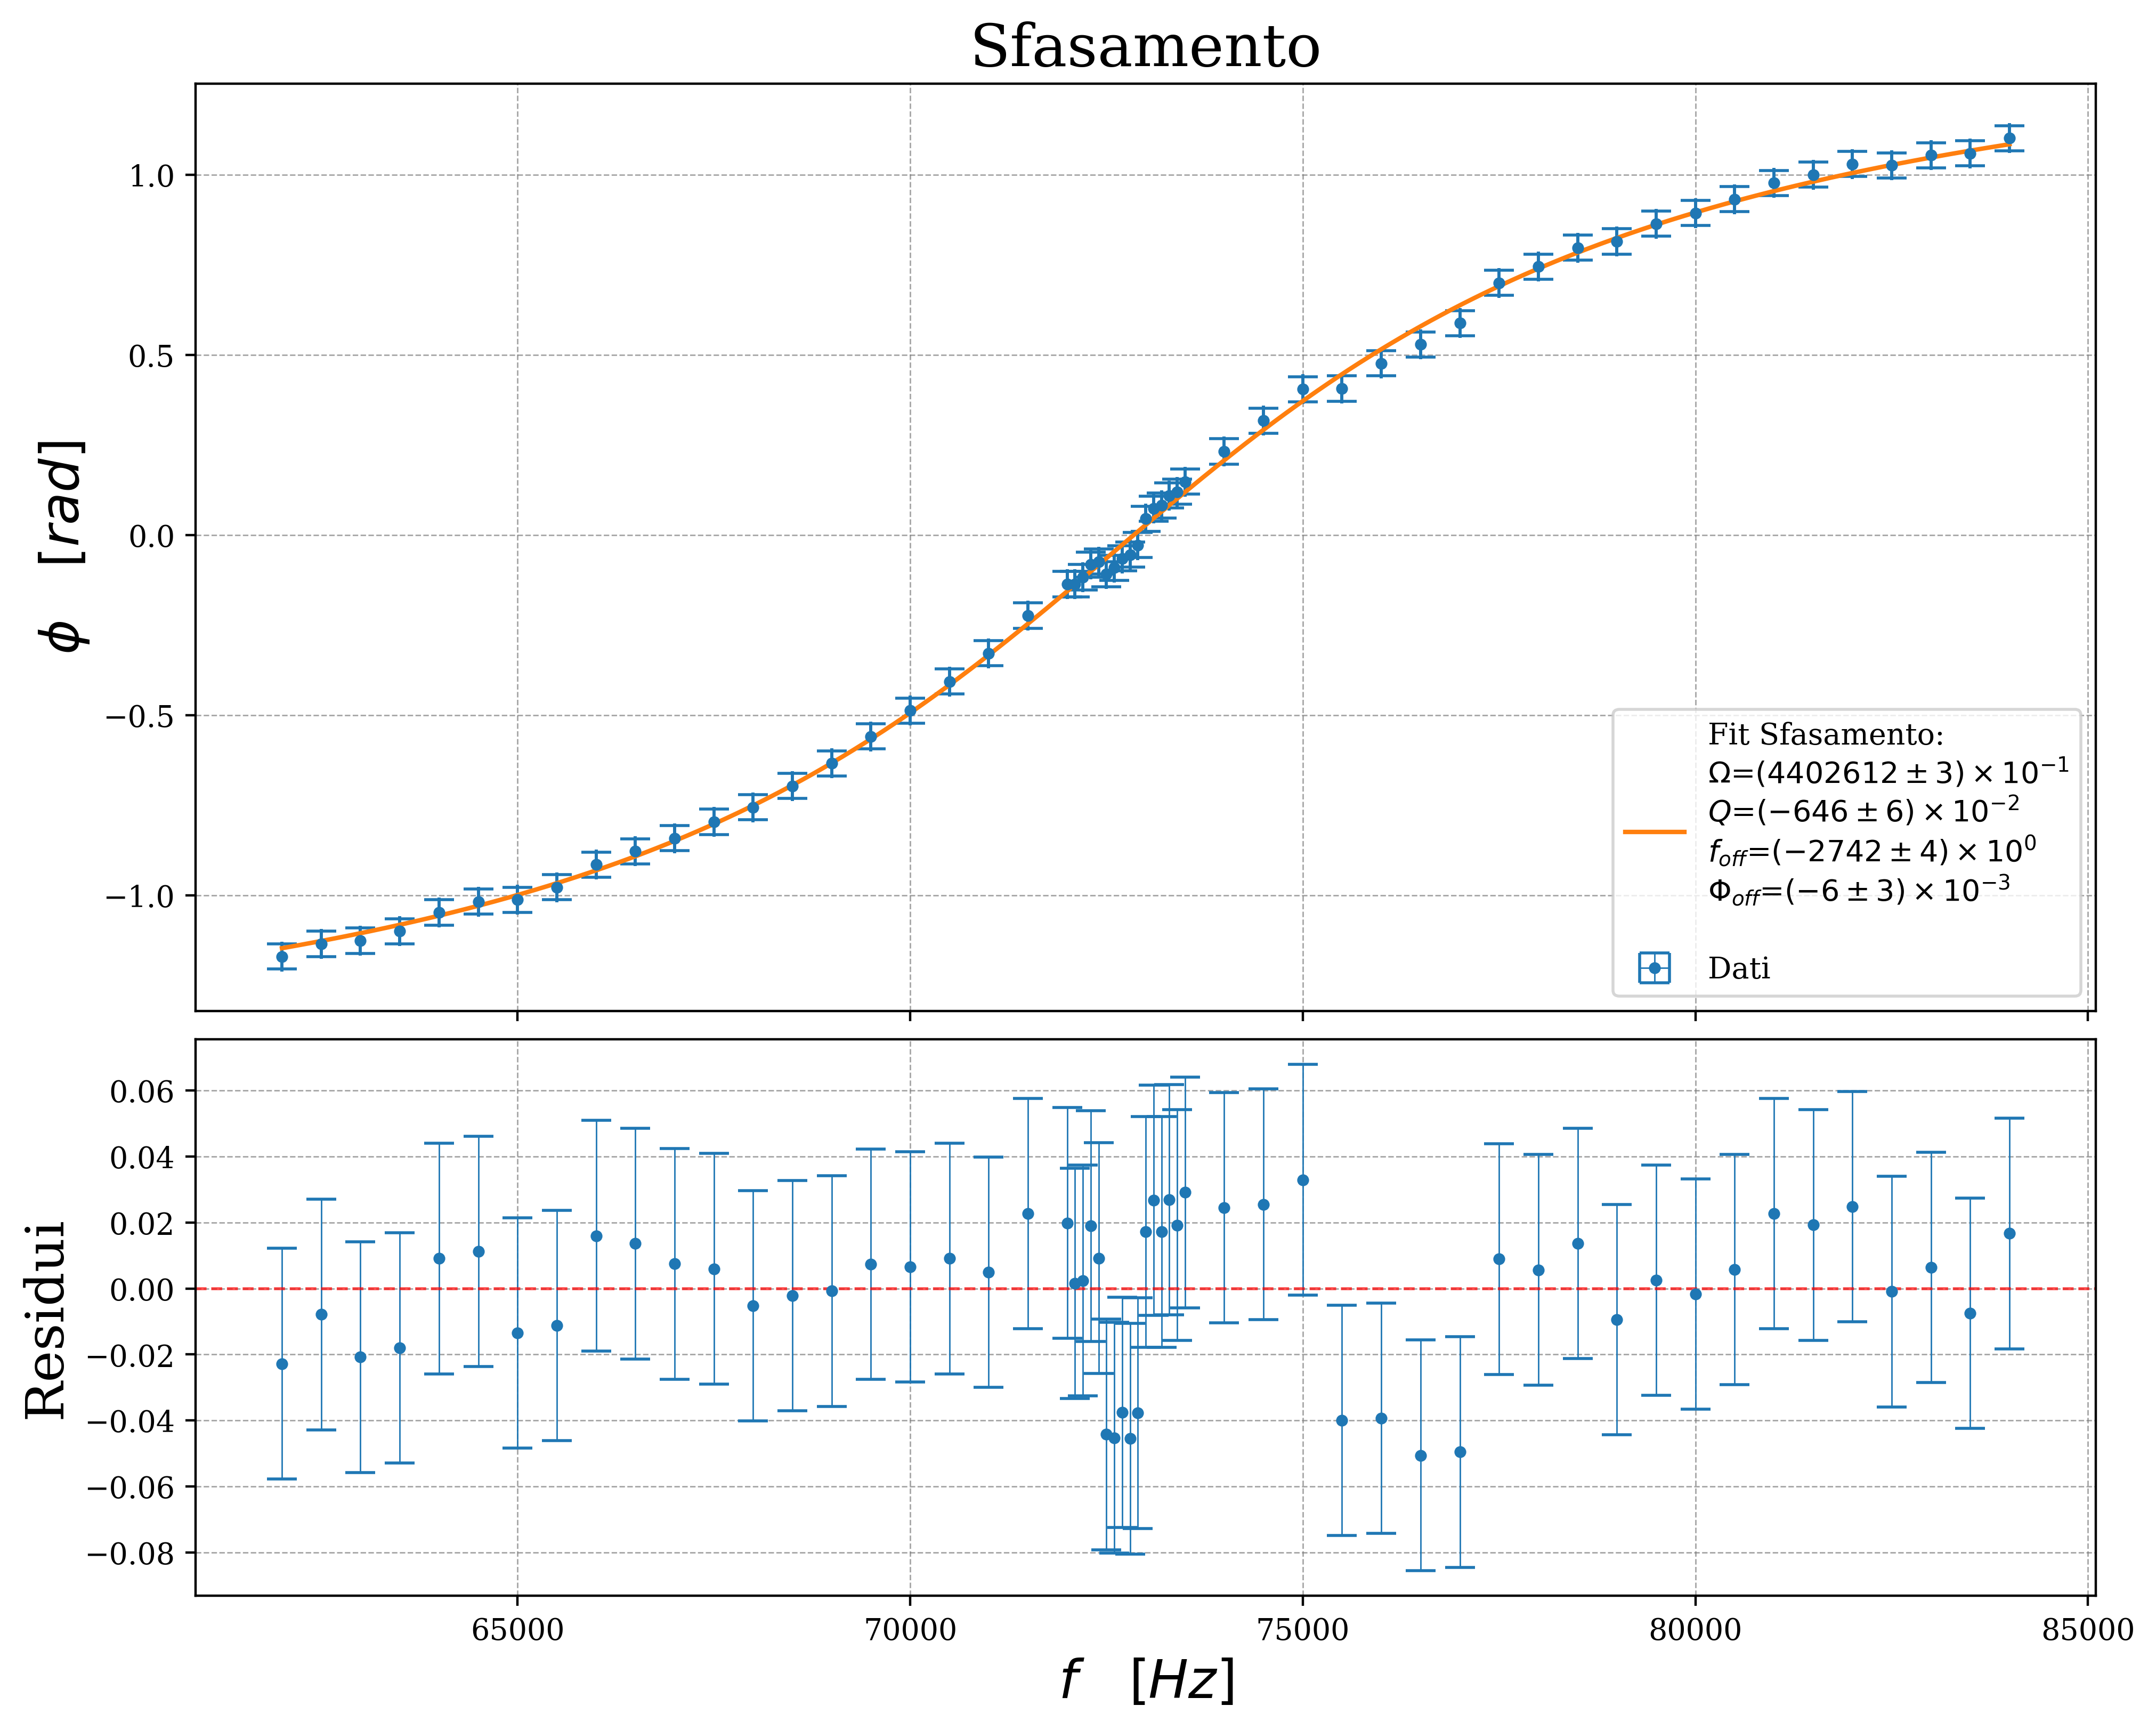

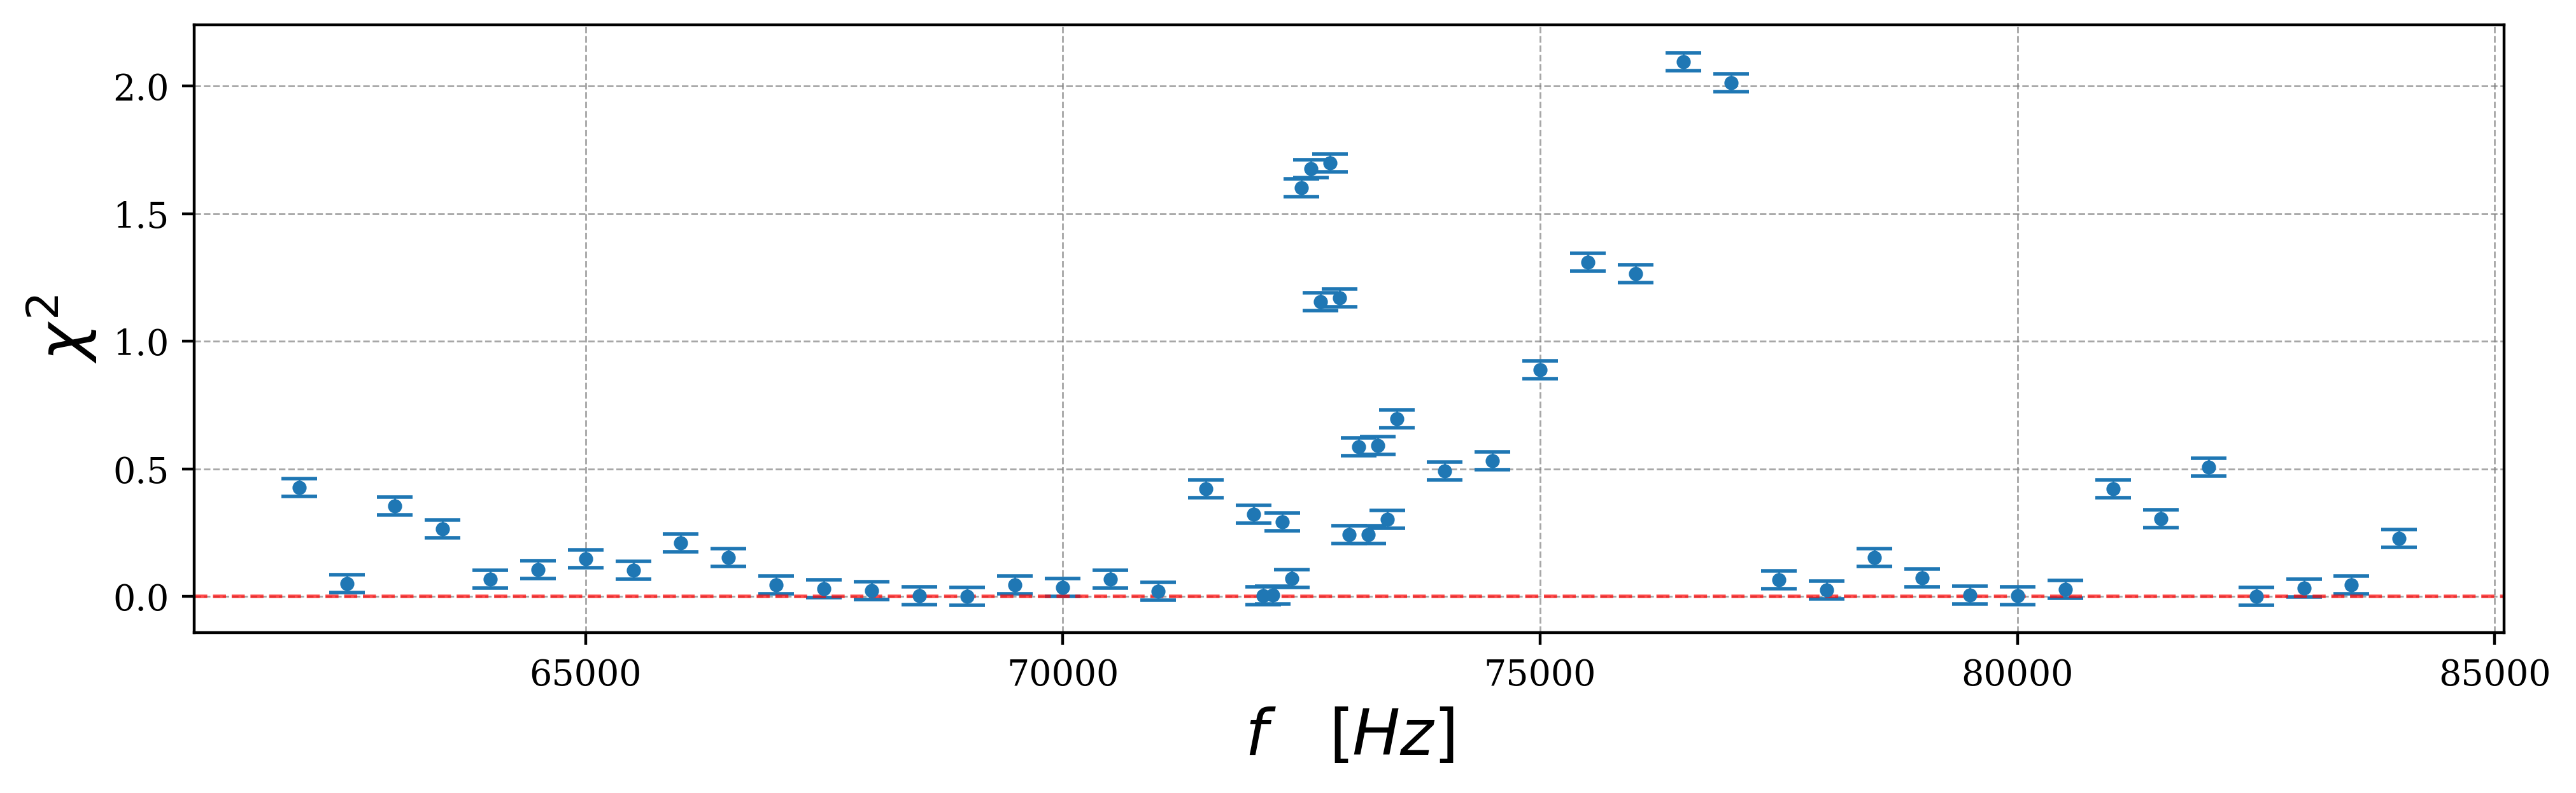

In [4]:
analisi = analizza("sfasamento", modello, param_labels, beta0, legenda_bbox = (1,0), legenda_loc="lower right", legenda_fontsize = 10)

In [5]:
print(analisi)

Parametri regressione :
440261.17874551425 ± 0.3032555133943423
-6.464126426280161 ± 0.056278502607281636
-2742.151569697357 ± 4.460056311902187
-0.006419557738277784 ± 0.003306265597862129

Somma residui :
-0.0000
Somma chi quadri e chi ridotto :
23.7082
0.4473



In [6]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1]], [spar[0], spar[1]]]
parametri_offset = [par[2], par[3]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "sfasamento.pkl")